<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Thesis/blob/main/Train%E2%80%93Validation%E2%80%93Test_Split_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
train_path = "/content/drive/MyDrive/ArsenicSkinImagesBD/Train"
test_path  = "/content/drive/MyDrive/ArsenicSkinImagesBD/Test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    validation_split=0.20
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 5328 images belonging to 2 classes.


In [5]:
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1331 images belonging to 2 classes.


In [6]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2233 images belonging to 2 classes.


In [7]:
NUM_CLASSES = train_generator.num_classes

print("Number of classes:", NUM_CLASSES)
print(train_generator.class_indices)

print("Training Images :", train_generator.samples)
print("Validation Images :", val_generator.samples)
print("Testing Images :", test_generator.samples)

Number of classes: 2
{'infected': 0, 'not_infected': 1}
Training Images : 5328
Validation Images : 1331
Testing Images : 2233


In [8]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9977528089887641), 1: np.float64(1.002257336343115)}


In [9]:
def transformer_block(x):

    attn = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=x.shape[-1] // 4
    )(x, x)

    x1 = layers.Add()([x, attn])
    x1 = layers.LayerNormalization()(x1)

    ffn = layers.Dense(
        x.shape[-1] * 2,
        activation='gelu'
    )(x1)

    ffn = layers.Dense(
        x.shape[-1]
    )(ffn)

    x2 = layers.Add()([x1, ffn])
    x2 = layers.LayerNormalization()(x2)

    return x2

In [10]:
def build_model(num_classes):

    inputs = layers.Input(shape=(224,224,3))

    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )

    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    h, w, c = x.shape[1], x.shape[2], x.shape[3]

    patches = h * w

    x = layers.Reshape((patches, c))(x)

    pos = tf.range(start=0, limit=patches, delta=1)

    pos_emb = layers.Embedding(
        input_dim=patches,
        output_dim=c
    )(pos)

    x = x + pos_emb

    x = transformer_block(x)
    x = transformer_block(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        512,
        activation='relu'
    )(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        256,
        activation='relu'
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    return models.Model(inputs, outputs)

In [11]:
model = build_model(NUM_CLASSES)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,949,586 (125.69 MB)

 Trainable params: 27,848,114 (106.23 MB)

 Non-trainable params: 5,101,472 (19.46 MB)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
callbacks_list = [

    callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.8452 - loss: 0.4007 
Epoch 1: val_accuracy improved from None to 0.86551, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 2898s 16s/step - accuracy: 0.9043 - loss: 0.2707 - val_accuracy: 0.8655 - val_loss: 0.3444 - learning_rate: 3.0000e-04
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9523 - loss: 0.1742 
Epoch 2: val_accuracy improved from 0.86551 to 0.91660, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
167/167 ━━━━━━━━━━━━━━━━━━━━ 2694s 16s/step - accuracy: 0.9602 - loss: 0.1412 - val_accuracy: 0.9166 - val_loss: 0.3911 - learning_rate: 3.0000e-04
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9694 - loss: 0.1015 
Epoch 3: val_accuracy did not improve from 0.91660
167/167 ━━━━━━━━━━━━━━━━━━━━ 2695s 16s/step - accuracy: 0.9668 - loss: 0.1104 - val_accuracy: 0.9068 - val_loss: 

In [15]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", round(loss,4))
print("Test Accuracy :", round(accuracy*100,2), "%")

70/70 ━━━━━━━━━━━━━━━━━━━━ 624s 9s/step - accuracy: 0.8939 - loss: 0.5059
Test Loss : 0.5059
Test Accuracy : 89.39 %


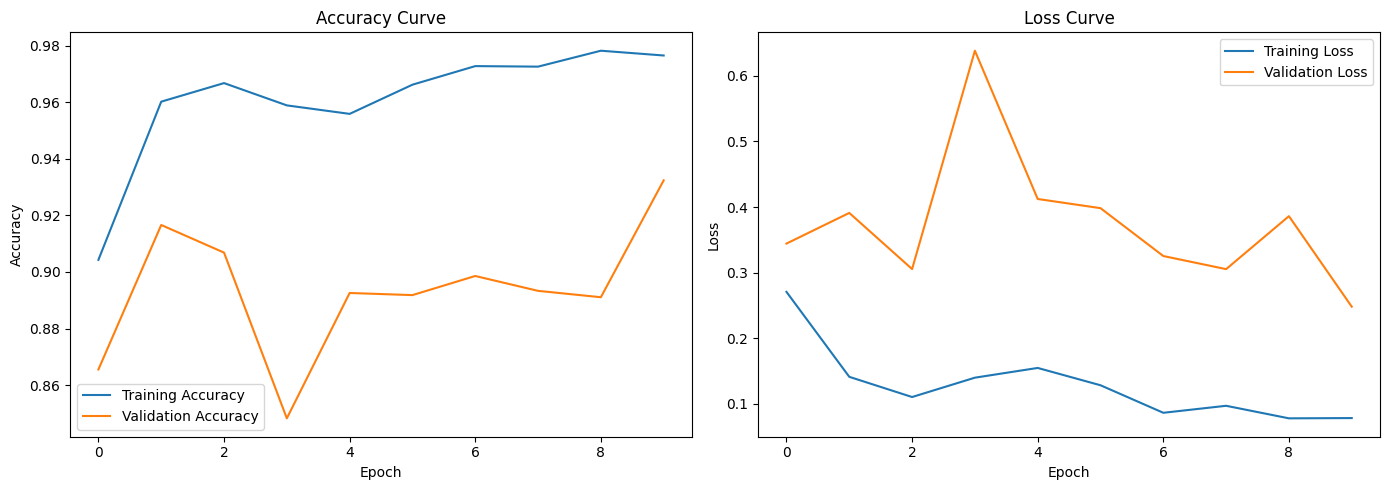

In [16]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

70/70 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step


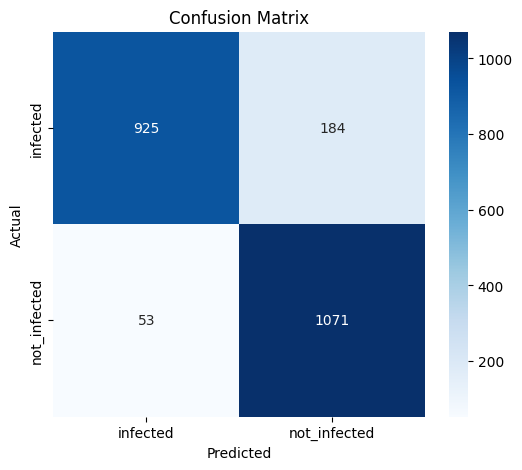

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [19]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    infected       0.95      0.83      0.89      1109
not_infected       0.85      0.95      0.90      1124

    accuracy                           0.89      2233
   macro avg       0.90      0.89      0.89      2233
weighted avg       0.90      0.89      0.89      2233



In [20]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Precision :", round(precision*100,2),"%")
print("Recall :", round(recall*100,2),"%")
print("F1 Score :", round(f1*100,2),"%")

Precision : 89.93 %
Recall : 89.39 %
F1 Score : 89.35 %


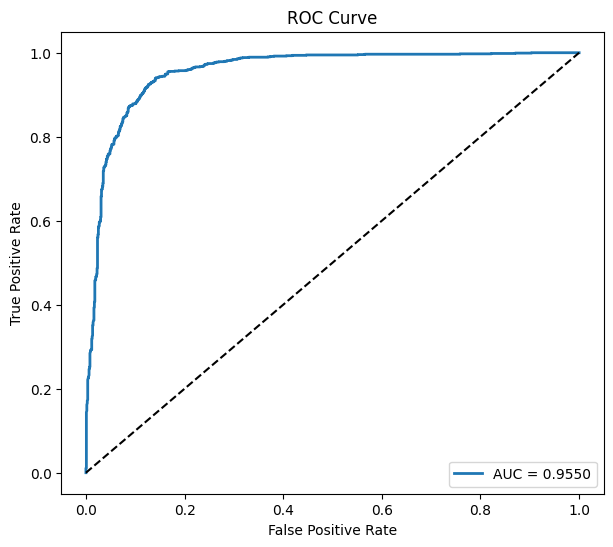

In [21]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_pred_prob[:,1]
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

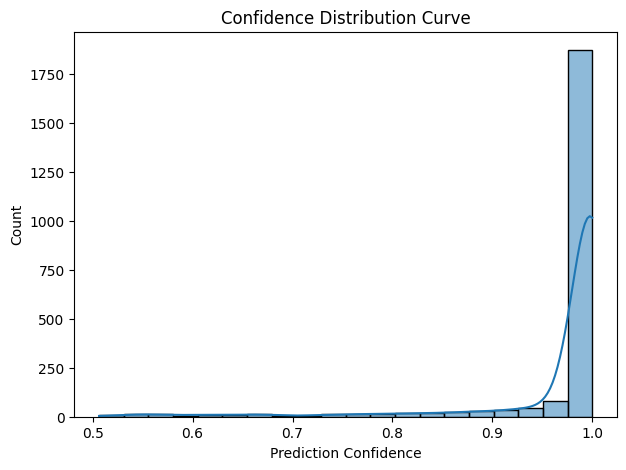

In [22]:
confidence = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(7,5))

sns.histplot(
    confidence,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution Curve")

plt.show()

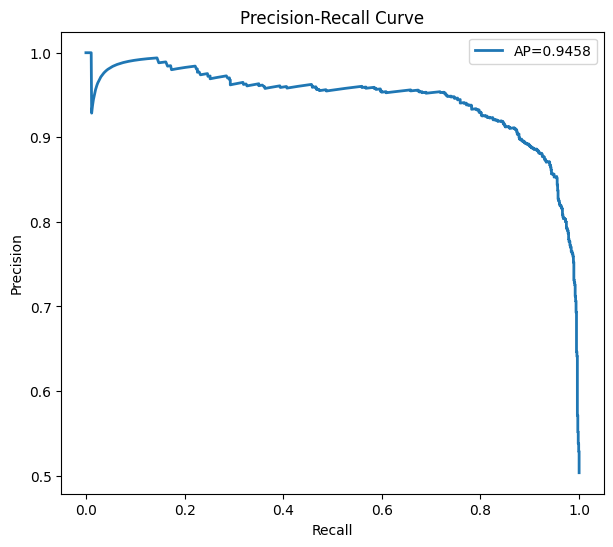

In [23]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_true,
    y_pred_prob[:,1]
)

ap = average_precision_score(
    y_true,
    y_pred_prob[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    lw=2,
    label=f'AP={ap:.4f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()